In [1]:
!pip install openpyxl
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
df_entier = pd.read_excel(r'C:\Users\aymer\git-practice\rugbydata_top14_stats.xlsx')

In [2]:
sections_team = ['team-overview', 'team-tries', 'team-points', 'team-possession', 'team-conquest', 'team-discipline']
df_team = df_entier[df_entier['section'].isin(sections_team)]
print(df_team.columns)

Index(['saison', 'phase', 'section', 'statistique', 'rang', 'nom', 'valeur',
       'entity_id'],
      dtype='str')


In [3]:
ranking = {('2024-2025', 'Stade Toulousain'): 1,('2024-2025', 'Union Bordeaux Bègles'): 2,('2024-2025', 'RC Toulon'): 3,('2024-2025', 'Aviron Bayonnais'): 4,('2024-2025', 'ASM Clermont'): 5,
    ('2024-2025', 'Castres Olympique'): 6,('2024-2025', 'Stade Rochelais'): 7,('2024-2025', 'Section Paloise'): 8,('2024-2025', 'Montpellier HR'): 9,('2024-2025', 'Racing 92'): 10,
    ('2024-2025', 'LOU Rugby'): 11,('2024-2025', 'Stade Français'): 12,('2024-2025', 'USA Perpignan'): 13,('2024-2025', 'Vannes'): 14,('2025-2026', 'Stade Toulousain'): 1,
    ('2025-2026', 'Montpellier HR'): 2,('2025-2026', 'Section Paloise'): 3,('2025-2026', 'Stade Français'): 4,('2025-2026', 'ASM Clermont'): 5,('2025-2026', 'Union Bordeaux Bègles'): 6,('2025-2026', 'Racing 92'): 7,('2025-2026', 'Stade Rochelais'): 8,('2025-2026', 'RC Toulon'): 9,('2025-2026', 'Castres Olympique'): 10,('2025-2026', 'Lyon OU'): 11,
    ('2025-2026', 'Aviron Bayonnais'): 12,('2025-2026', 'USA Perpignan'): 13,('2025-2026', 'US Montauban'): 14,}
df_ranking = pd.DataFrame([{'saison': k[0], 'nom': k[1], 'ranking': v} for k, v in ranking.items()])
df_team = df_team.merge(df_ranking, on=['saison', 'nom'], how='left')

In [4]:
print(df_team.columns)

Index(['saison', 'phase', 'section', 'statistique', 'rang', 'nom', 'valeur',
       'entity_id', 'ranking'],
      dtype='str')


In [5]:
stats_cles = [
    'Points marqués', 'Points encaissés', 'Essais marqués', 'Essais encaissés','Réussite des buteurs', 'Réussite en touches',
    'Pénalités obtenues', 'Pénalités concédées','Réussite en mêlées', 'Touches gagnées']

df_filtre = df_team[df_team['statistique'].isin(stats_cles)]

df_pivot = df_filtre.pivot_table(
    index=['saison', 'nom', 'ranking'],
    columns='statistique',
    values='valeur'
).reset_index()

df_pivot.columns.name = None
print(df_pivot.columns)

Index(['saison', 'nom', 'ranking', 'Essais encaissés', 'Essais marqués',
       'Points encaissés', 'Points marqués', 'Pénalités concédées',
       'Pénalités obtenues', 'Réussite des buteurs', 'Réussite en mêlées',
       'Réussite en touches', 'Touches gagnées'],
      dtype='str')


In [6]:
df_pivot_2026 = df_pivot[df_pivot['saison'] == '2025-2026'] #je viens de remarquer que toutes les datas de la saison 2024-25 sont erronées
print(df_pivot_2026['saison'].unique())

<StringArray>
['2025-2026']
Length: 1, dtype: str


In [7]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler

In [8]:
variables_x = ['Essais marqués', 'Essais encaissés', 'Points marqués', 'Points encaissés',
            'Pénalités concédées', 'Pénalités obtenues', 'Réussite des buteurs', 
            'Réussite en mêlées', 'Réussite en touches', 'Touches gagnées']
X=df_pivot_2026[variables_x]
Y=df_pivot_2026['ranking']

In [9]:
model = LinearRegression()
model.fit(X,Y)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [10]:
print(f"R² : {model.score(X, Y):.3f}")
for var, coef in zip(variables_x, model.coef_):
    print(f"{var}: {coef:.3f}")

R² : 0.996
Essais marqués: -0.143
Essais encaissés: -0.546
Points marqués: -0.005
Points encaissés: 0.099
Pénalités concédées: -0.057
Pénalités obtenues: -0.138
Réussite des buteurs: 0.369
Réussite en mêlées: -0.215
Réussite en touches: -0.366
Touches gagnées: 0.133


In [11]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
model_scaled = LinearRegression()
model_scaled.fit(X_scaled, Y)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [12]:
print(f"R² : {model_scaled.score(X_scaled, Y):.3f}")
for var, coef in zip(variables_x, model_scaled.coef_):
    print(f"{var}: {coef:.3f}")

R² : 0.996
Essais marqués: -2.542
Essais encaissés: -13.510
Points marqués: -0.541
Points encaissés: 14.751
Pénalités concédées: -1.070
Pénalités obtenues: -3.326
Réussite des buteurs: 1.145
Réussite en mêlées: -0.842
Réussite en touches: -1.158
Touches gagnées: 3.544


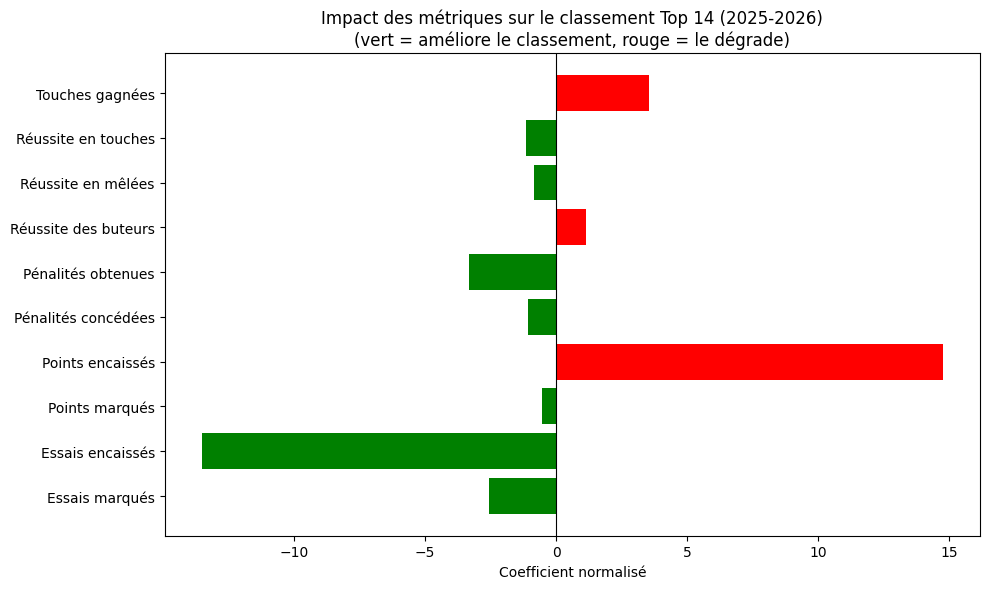

In [13]:
coefs = model_scaled.coef_
colors = ['red' if c > 0 else 'green' for c in coefs]

plt.figure(figsize=(10, 6))
plt.barh(variables_x, coefs, color=colors)
plt.axvline(x=0, color='black', linewidth=0.8)
plt.xlabel("Coefficient normalisé")
plt.title("Impact des métriques sur le classement Top 14 (2025-2026)\n(vert = améliore le classement, rouge = le dégrade)")
plt.tight_layout()
plt.show()

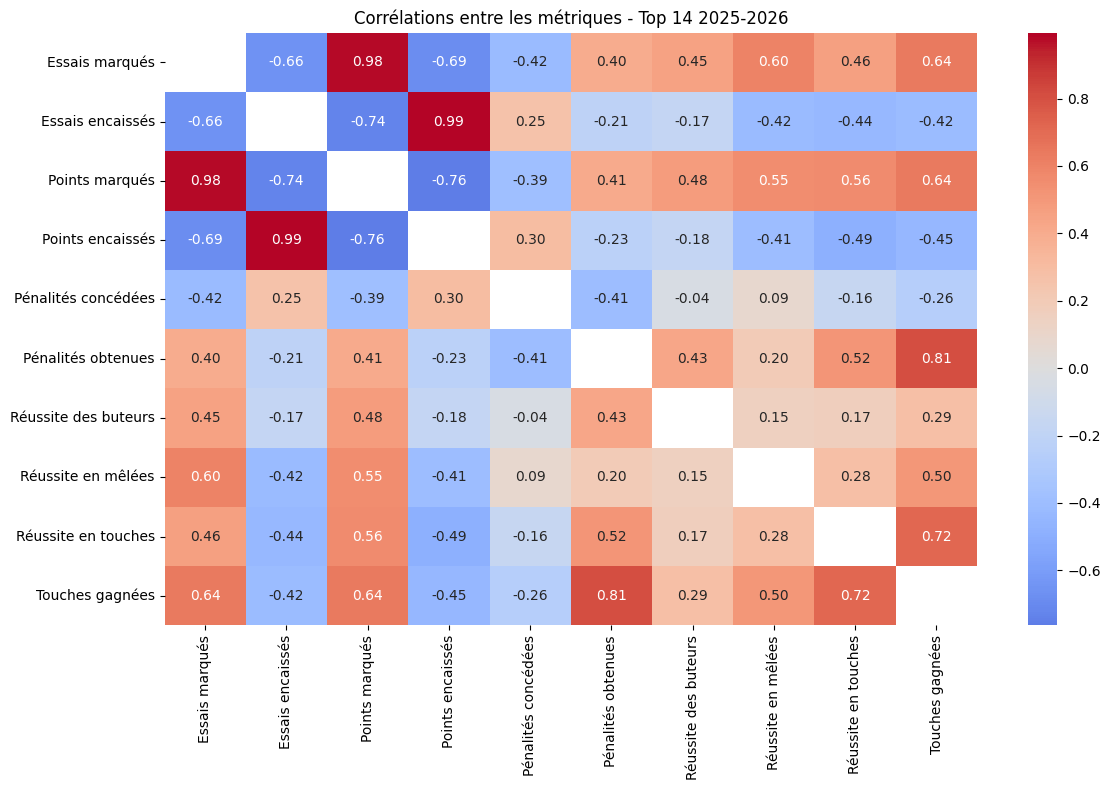

In [14]:
import seaborn as sns

corr = df_pivot_2026[variables_x].corr()

mask = np.eye(len(corr), dtype=bool)

plt.figure(figsize=(12, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, mask=mask)
plt.title("Corrélations entre les métriques - Top 14 2025-2026")
plt.tight_layout()
plt.show()